# Big-Data-Praktikum: Vorverarbeitung und Autoencoder-Pseudo-Labelling

Ziel dieses ersten Implementierungsschritts:
1. JPEG-Schichtbilder aus `recoating/` laden.
2. Jedes Schichtbild in 9 Bauteil-Patches zerlegen.
3. Patches normalisieren und als PyTorch-Dataset bereitstellen.
4. Einen Convolutional Autoencoder trainieren.
5. Pro Patch Rekonstruktionsfehler und Latentraum-Distanz berechnen.
6. Daraus per Otsu-Schwelle Pseudo-Labels erzeugen.

In [59]:
from pathlib import Path
import re
import random
from dataclasses import dataclass

In [60]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

from sklearn.preprocessing import MinMaxScaler
from skimage.filters import threshold_otsu

from scipy import ndimage as ndi
from scipy.signal import find_peaks

In [61]:
# Reproduzierbarkeit
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [62]:
@dataclass
class Config:
    data_dir: Path = Path("recoating")
    image_glob: str = "*.jpg"
    patch_size: int = 128
    crop_fraction: float = 0.32
    calibration_images: int = 45
    calibration_scale: float = 0.35
    temporal_threshold_percentile: float = 99.0
    search_border_fraction: float = 0.08
    min_component_pixels: int = 80
    min_interval_width: int = 8
    fallback_grid_margin_fraction: float = 0.14
    batch_size: int = 64
    num_workers: int = 0
    train_fraction: float = 0.85
    epochs: int = 10
    learning_rate: float = 1e-3
    latent_dim: int = 64
    alpha: float = 0.7  # Gewichtung: Rekonstruktionsfehler vs. Latentraum-Distanz
    output_dir: Path = Path("outputs")

cfg = Config()
cfg.output_dir.mkdir(exist_ok=True)

## 1. Bilder finden und Schichtnummern extrahieren

Erwartet wird ein Ordner `recoating/` mit ca. 1081 Graustufenbildern. Die Sortierung erfolgt robust über die erste Zahl im Dateinamen; falls keine Zahl gefunden wird, wird lexikografisch sortiert.

In [63]:
def extract_layer_number(path: Path) -> int:
    match = re.search(r"\d+", path.stem)
    return int(match.group()) if match else -1

In [64]:
image_paths = sorted(cfg.data_dir.glob(cfg.image_glob), key=lambda p: (extract_layer_number(p), p.name))
print(f"Gefundene Bilder: {len(image_paths)}")
if image_paths:
    print("Erstes Bild:", image_paths[0])
    print("Letztes Bild:", image_paths[-1])
else:
    raise FileNotFoundError(f"Keine Bilder gefunden unter {cfg.data_dir.resolve()} mit Muster {cfg.image_glob}")

Gefundene Bilder: 1081
Erstes Bild: recoating/2021-02-18_08-38-33_layer_00002.jpg
Letztes Bild: recoating/2021-02-18_14-44-42_layer_01082.jpg


## 2. Vorverarbeitung: 9 Bauteil-Patches pro Schichtbild

Laut Aufgabenentwurf enthält jedes Schichtbild neun zentriert angeordnete Bauteile. Die Herausforderung ist, dass die Bauteile im Kamerabild nur als kleine Strukturen im mittleren Pulverbettbereich erscheinen. Ein Raster über das komplette Bild oder über eine grobe Gesamt-ROI ist deshalb zu ungenau.

Die genaue Lösung kalibriert die tatsächlichen Bauteilpositionen über die zeitliche Änderung der Bildsequenz: Statische Bereiche wie Pulverbett, Kamerarand und Beleuchtungsgradient bleiben über viele Schichten ähnlich, während die Bauteile durch ihre wachsenden Querschnitte an festen Positionen auffallen. Aus einer temporalen Standardabweichungskarte werden drei Zeilen- und drei Spaltenzentren bestimmt. Danach werden alle Bilder mit diesen kalibrierten Zentren und einem engen Crop zugeschnitten.

In [65]:
def load_grayscale(path: Path) -> np.ndarray:
    image = Image.open(path).convert("L")
    arr = np.asarray(image, dtype=np.float32) / 255.0
    return arr

In [66]:
@dataclass
class GridSpec:
    y_centers: list[int]
    x_centers: list[int]
    crop_side: int
    temporal_map: np.ndarray | None = None


def normalize_robust(arr: np.ndarray) -> np.ndarray:
    low, high = np.percentile(arr, [2, 98])
    return np.clip((arr - low) / max(high - low, 1e-6), 0.0, 1.0)


def resize_for_calibration(arr: np.ndarray, scale: float) -> np.ndarray:
    if scale == 1.0:
        return arr
    return ndi.zoom(arr, zoom=scale, order=1)


def remove_small_components(mask: np.ndarray, min_pixels: int) -> np.ndarray:
    labeled, n_labels = ndi.label(mask)
    if n_labels == 0:
        return mask
    counts = np.bincount(labeled.ravel())
    keep = counts >= min_pixels
    keep[0] = False
    return keep[labeled]


def make_temporal_change_map(paths: list[Path]) -> np.ndarray:
    """Erzeugt eine Karte der zeitlichen Bildänderung.

    Statische Kanten des Kamerabildes werden dadurch weitgehend unterdrückt,
    während die Bauteilpositionen sichtbar werden, weil sich deren Querschnitte
    über die Schichten verändern."""
    n = min(cfg.calibration_images, len(paths))
    sample_indices = np.linspace(0, len(paths) - 1, n).round().astype(int)
    frames = []
    for idx in sample_indices:
        arr = load_grayscale(paths[idx])
        arr = normalize_robust(arr)
        arr_small = resize_for_calibration(arr, cfg.calibration_scale)
        frames.append(arr_small.astype(np.float32))

    stack = np.stack(frames, axis=0)
    temporal_std = np.std(stack, axis=0)
    temporal_std = ndi.gaussian_filter(temporal_std, sigma=1.2)

    # Kameraränder ignorieren; dort entstehen oft hohe, aber irrelevante Kontraste.
    h, w = temporal_std.shape
    by = int(cfg.search_border_fraction * h)
    bx = int(cfg.search_border_fraction * w)
    temporal_std[:by, :] = 0
    temporal_std[-by:, :] = 0
    temporal_std[:, :bx] = 0
    temporal_std[:, -bx:] = 0

    temporal_std = temporal_std / max(float(temporal_std.max()), 1e-6)
    return temporal_std

In [67]:
def fallback_three_centers_from_profile(smooth: np.ndarray, axis_name: str) -> list[int]:
    """Robuster Fallback, falls die Profil-Peaks nicht klar getrennt sind.

    Bei sehr kleinen Bauteilen oder schwacher Änderung kann das x-Profil als ein breiter
    Bereich erscheinen. Dann wird der aktive Bereich bestimmt und in drei gleichmäßige
    Zentren unterteilt. Das ist immer noch deutlich besser als ein Raster über das ganze Bild.
    """
    active_threshold = max(float(np.percentile(smooth, 75)), 0.08)
    active = smooth >= active_threshold
    idx = np.where(active)[0]

    if len(idx) < 3:
        active_threshold = max(float(np.percentile(smooth, 60)), 0.04)
        idx = np.where(smooth >= active_threshold)[0]

    if len(idx) < 3:
        # Letzter Fallback: zentraler Suchbereich ohne harte Exception.
        lo = int(len(smooth) * 0.25)
        hi = int(len(smooth) * 0.75)
    else:
        lo = int(idx.min())
        hi = int(idx.max())

    width = hi - lo
    margin = int(width * cfg.fallback_grid_margin_fraction)
    lo = min(max(0, lo + margin), len(smooth) - 1)
    hi = max(min(len(smooth) - 1, hi - margin), lo + 2)

    centers = np.linspace(lo, hi, 3).round().astype(int).tolist()
    print(f"Fallback-Zentren für Achse {axis_name}: {centers}")
    return centers


def find_three_centers_from_profile(profile: np.ndarray, axis_name: str, debug: bool = False) -> list[int]:
    smooth = ndi.gaussian_filter1d(profile.astype(np.float32), sigma=2)
    smooth = smooth - np.percentile(smooth, 5)
    smooth = smooth / max(float(smooth.max()), 1e-6)

    # 1) Peak-Suche mit mehreren Toleranzen. Die x-Achse ist oft schwieriger,
    # weil die kleinen Bauteile weniger klar als getrennte Peaks erscheinen.
    for distance_fraction, prominence in [
        (7, 0.04),
        (9, 0.025),
        (12, 0.015),
        (16, 0.008),
    ]:
        min_distance = max(len(smooth) // distance_fraction, 1)
        peaks, _ = find_peaks(smooth, distance=min_distance, prominence=prominence)
        if len(peaks) >= 3:
            peak_scores = smooth[peaks]
            best = sorted(peaks[np.argsort(peak_scores)[-3:]])
            centers = [int(p) for p in best]
            if debug:
                print(f"Peak-Zentren für Achse {axis_name}: {centers}")
            return centers

    # 2) Intervallbildung über adaptive Schwellen.
    for threshold in [0.35, 0.25, 0.18, 0.12, 0.08, 0.05]:
        active = smooth > threshold
        intervals = []
        start = None
        for idx, value in enumerate(active):
            if value and start is None:
                start = idx
            elif not value and start is not None:
                end = idx
                if end - start >= cfg.min_interval_width:
                    intervals.append((start, end, float(smooth[start:end].sum())))
                start = None
        if start is not None:
            end = len(active)
            if end - start >= cfg.min_interval_width:
                intervals.append((start, end, float(smooth[start:end].sum())))

        if len(intervals) >= 3:
            best = sorted(intervals, key=lambda t: t[2], reverse=True)[:3]
            centers = [int(round((start + end) / 2)) for start, end, _ in best]
            centers = sorted(centers)
            if debug:
                print(f"Intervall-Zentren für Achse {axis_name}: {centers}")
            return centers

    # 3) Kein Abbruch mehr: stattdessen kontrollierter Fallback.
    return fallback_three_centers_from_profile(smooth, axis_name)


def estimate_global_grid(paths: list[Path], show_debug: bool = True) -> GridSpec:
    temporal = make_temporal_change_map(paths)

    threshold = np.percentile(temporal[temporal > 0], cfg.temporal_threshold_percentile)
    mask = temporal >= threshold
    mask = ndi.binary_closing(mask, structure=np.ones((3, 3), dtype=bool), iterations=1)
    mask = ndi.binary_fill_holes(mask)
    mask = remove_small_components(mask, cfg.min_component_pixels)

    # Gewichtete Profile aus der temporalen Karte: kleine Bauteile bleiben als Peaks erhalten.
    weighted = temporal * mask.astype(np.float32)
    if weighted.sum() == 0:
        weighted = temporal

    y_profile = weighted.sum(axis=1)
    x_profile = weighted.sum(axis=0)

    y_small = find_three_centers_from_profile(y_profile, axis_name="y", debug=show_debug)
    x_small = find_three_centers_from_profile(x_profile, axis_name="x", debug=show_debug)

    scale = cfg.calibration_scale
    y_centers = [int(round(y / scale)) for y in y_small]
    x_centers = [int(round(x / scale)) for x in x_small]

    y_spacing = np.diff(sorted(y_centers))
    x_spacing = np.diff(sorted(x_centers))
    min_spacing = min(float(y_spacing.min()), float(x_spacing.min()))
    crop_side = int(min_spacing * cfg.crop_fraction)
    crop_side = max(32, crop_side)

    print("Kalibrierte y-Zentren:", y_centers)
    print("Kalibrierte x-Zentren:", x_centers)
    print("Patch-Crop-Seitenlänge im Originalbild:", crop_side)

    if show_debug:
        # Debugbild auf Originalgröße hochskalieren, damit es direkt mit dem Kamerabild vergleichbar ist.
        debug_map = ndi.zoom(temporal, zoom=1 / scale, order=1)
        sample_path = paths[len(paths) // 2]
        sample = load_grayscale(sample_path)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(sample, cmap="gray")
        axes[0].set_title(f"Beispielbild: {sample_path.name}")
        axes[0].axis("off")

        axes[1].imshow(debug_map, cmap="magma")
        axes[1].set_title("temporale Änderungskarte")
        axes[1].axis("off")

        axes[2].imshow(sample, cmap="gray")
        for y in y_centers:
            axes[2].axhline(y, linewidth=1)
        for x in x_centers:
            axes[2].axvline(x, linewidth=1)
        axes[2].set_title("kalibrierte 3x3-Zentren")
        axes[2].axis("off")
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(y_profile)
        for y in y_small:
            axes[0].axvline(y, linestyle="--")
        axes[0].set_title("y-Profil der temporalen Änderung")
        axes[0].set_xlabel("y im skalierten Kalibrierungsbild")

        axes[1].plot(x_profile)
        for x in x_small:
            axes[1].axvline(x, linestyle="--")
        axes[1].set_title("x-Profil der temporalen Änderung")
        axes[1].set_xlabel("x im skalierten Kalibrierungsbild")
        plt.tight_layout()
        plt.show()

    return GridSpec(
        y_centers=sorted(y_centers),
        x_centers=sorted(x_centers),
        crop_side=crop_side,
        temporal_map=temporal,
    )

In [68]:
def crop_center_square(arr: np.ndarray, center_y: int, center_x: int, size: int) -> np.ndarray:
    height, width = arr.shape
    half = size // 2
    y1 = max(0, center_y - half)
    y2 = min(height, center_y + half)
    x1 = max(0, center_x - half)
    x2 = min(width, center_x + half)
    crop = arr[y1:y2, x1:x2]

    # Padding, falls der Patch am Bildrand liegt
    pad_top = max(0, half - center_y)
    pad_bottom = max(0, center_y + half - height)
    pad_left = max(0, half - center_x)
    pad_right = max(0, center_x + half - width)
    if any(v > 0 for v in [pad_top, pad_bottom, pad_left, pad_right]):
        crop = np.pad(crop, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=0.0)

    return crop

In [69]:
def image_to_9_patches(path: Path, patch_size: int, grid_spec: GridSpec | None = None) -> list[dict]:
    arr = load_grayscale(path)
    grid = grid_spec if grid_spec is not None else GLOBAL_GRID

    records = []
    layer = extract_layer_number(path)
    for row, cy in enumerate(grid.y_centers):
        for col, cx in enumerate(grid.x_centers):
            crop = crop_center_square(arr, cy, cx, grid.crop_side)
            patch = Image.fromarray((crop * 255).astype(np.uint8)).resize((patch_size, patch_size), Image.Resampling.BILINEAR)
            patch_arr = np.asarray(patch, dtype=np.float32) / 255.0
            records.append({
                "image_path": str(path),
                "layer": layer,
                "position": row * 3 + col,
                "center_y": cy,
                "center_x": cx,
                "crop_side": grid.crop_side,
                "patch": patch_arr,
            })
    return records

Intervall-Zentren für Achse y: [182, 224, 382]
Fallback-Zentren für Achse x: [362, 430, 499]
Kalibrierte y-Zentren: [520, 640, 1091]
Kalibrierte x-Zentren: [1034, 1229, 1426]
Patch-Crop-Seitenlänge im Originalbild: 38


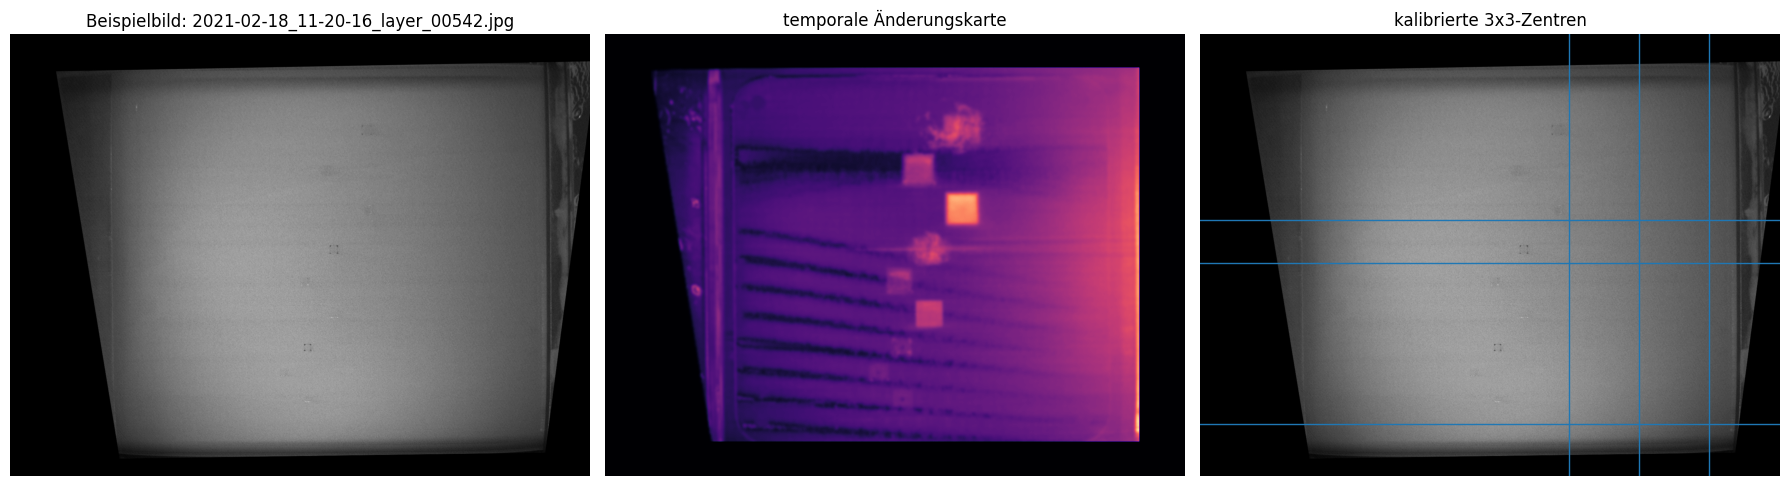

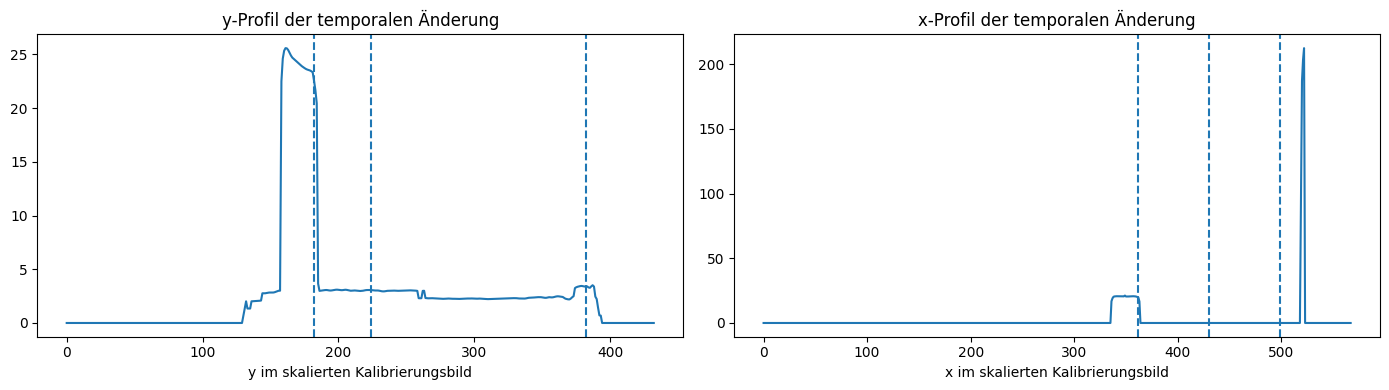

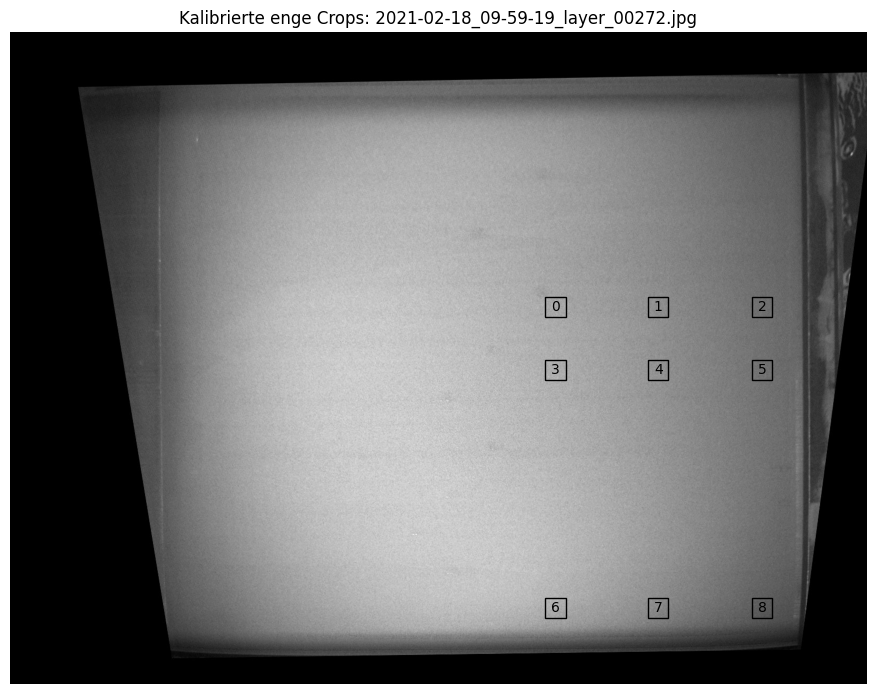

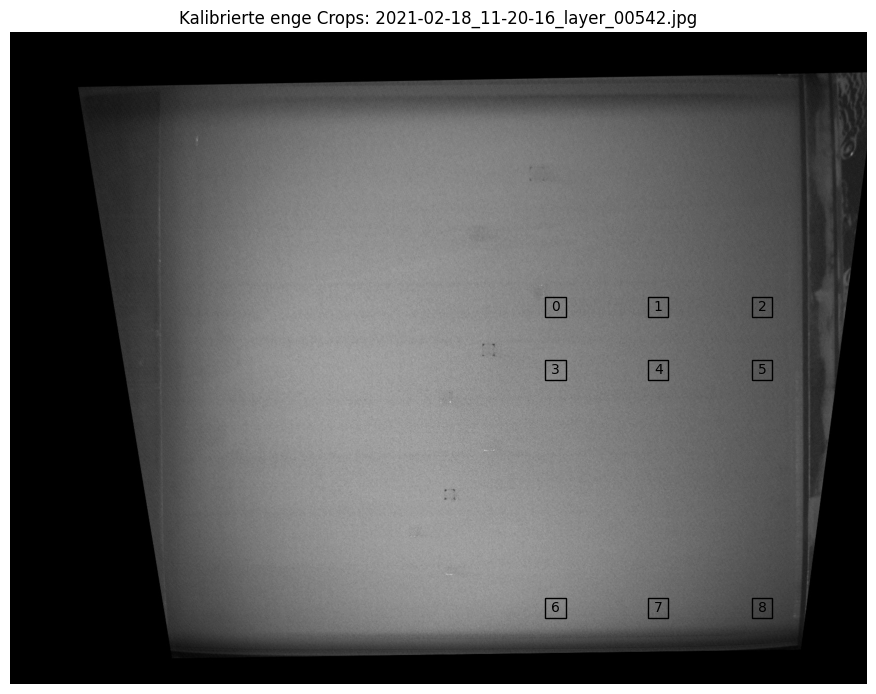

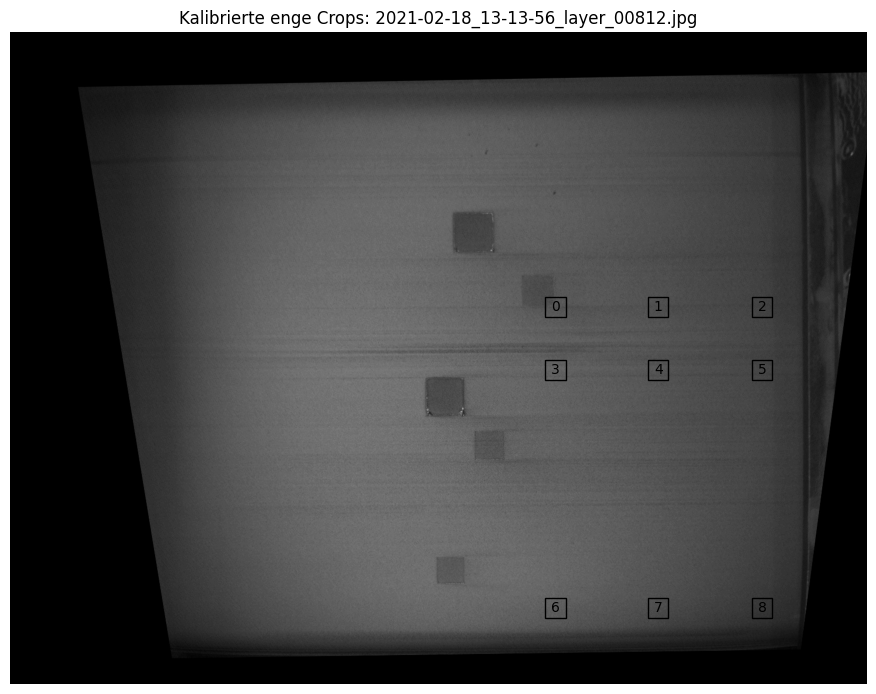

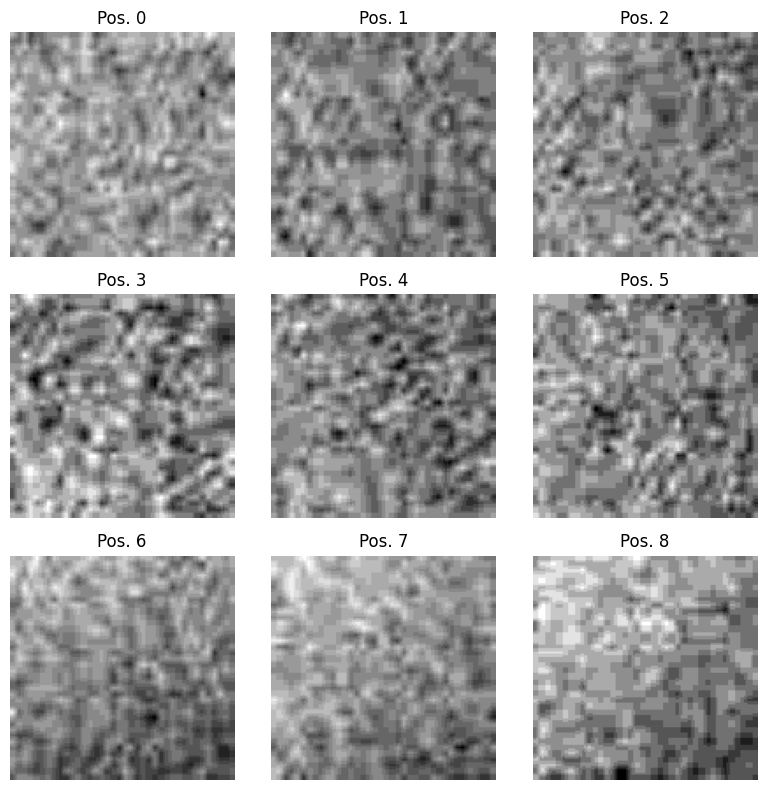

In [70]:
# Beispielvisualisierung und globale Grid-Kalibrierung
GLOBAL_GRID = estimate_global_grid(image_paths, show_debug=True)

def show_patch_grid_on_image(path: Path, grid_spec: GridSpec = GLOBAL_GRID):
    arr = load_grayscale(path)
    records = image_to_9_patches(path, cfg.patch_size, grid_spec=grid_spec)

    plt.figure(figsize=(9, 7))
    plt.imshow(arr, cmap="gray")
    plt.title(f"Kalibrierte enge Crops: {path.name}")

    for rec in records:
        half = rec["crop_side"] // 2
        x = rec["center_x"] - half
        y = rec["center_y"] - half
        plt.gca().add_patch(plt.Rectangle((x, y), rec["crop_side"], rec["crop_side"], fill=False, linewidth=1))
        plt.text(rec["center_x"], rec["center_y"], str(rec["position"]), ha="center", va="center")

    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Diagnose auf mehreren Schichten, damit falsche Zentren sofort sichtbar werden.
for sample_idx in [len(image_paths) // 4, len(image_paths) // 2, int(len(image_paths) * 0.75)]:
    show_patch_grid_on_image(image_paths[sample_idx], grid_spec=GLOBAL_GRID)

sample_path = image_paths[len(image_paths) // 2]
sample_records = image_to_9_patches(sample_path, cfg.patch_size, grid_spec=GLOBAL_GRID)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, rec in zip(axes.ravel(), sample_records):
    ax.imshow(rec["patch"], cmap="gray")
    ax.set_title(f"Pos. {rec['position']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [71]:
all_records = []
for i, path in enumerate(image_paths, start=1):
    all_records.extend(image_to_9_patches(path, cfg.patch_size, grid_spec=GLOBAL_GRID))
    if i % 100 == 0 or i == len(image_paths):
        print(f"Vorverarbeitung: {i}/{len(image_paths)} Bilder")

metadata = pd.DataFrame([{k: v for k, v in rec.items() if k != "patch"} for rec in all_records])
patches = np.stack([rec["patch"] for rec in all_records]).astype(np.float32)

print("Patches:", patches.shape)  # Erwartet: ca. (1081 * 9, 128, 128)
display(metadata.head())

Vorverarbeitung: 100/1081 Bilder
Vorverarbeitung: 200/1081 Bilder
Vorverarbeitung: 300/1081 Bilder
Vorverarbeitung: 400/1081 Bilder
Vorverarbeitung: 500/1081 Bilder
Vorverarbeitung: 600/1081 Bilder
Vorverarbeitung: 700/1081 Bilder
Vorverarbeitung: 800/1081 Bilder
Vorverarbeitung: 900/1081 Bilder
Vorverarbeitung: 1000/1081 Bilder
Vorverarbeitung: 1081/1081 Bilder
Patches: (9729, 128, 128)


,image_path,layer,position,center_y,center_x,crop_side
0,recoating/2021-02-18_08-38-33_layer_00002.jpg,2021,0,520,1034,38
1,recoating/2021-02-18_08-38-33_layer_00002.jpg,2021,1,520,1229,38
2,recoating/2021-02-18_08-38-33_layer_00002.jpg,2021,2,520,1426,38
3,recoating/2021-02-18_08-38-33_layer_00002.jpg,2021,3,640,1034,38
4,recoating/2021-02-18_08-38-33_layer_00002.jpg,2021,4,640,1229,38


## 3. Dataset und DataLoader

In [72]:
class PatchDataset(Dataset):
    def __init__(self, patches: np.ndarray, metadata: pd.DataFrame):
        self.patches = patches
        self.metadata = metadata.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.patches)

    def __getitem__(self, idx: int):
        x = torch.from_numpy(self.patches[idx]).unsqueeze(0)  # [1, H, W]
        return x, idx

In [73]:
dataset = PatchDataset(patches, metadata)
train_size = int(len(dataset) * cfg.train_fraction)
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
full_loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 8269, Val: 1460


## 4. Convolutional Autoencoder

In [74]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim: int = 64):
        super().__init__()
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_cnn(x)
        z = self.fc_mu(self.flatten(h))
        return z

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z


In [75]:
model = ConvAutoencoder(latent_dim=cfg.latent_dim).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
criterion = nn.MSELoss()

In [76]:
def run_epoch(loader: DataLoader, train: bool) -> float:
    model.train(train)
    losses = []
    for x, _ in loader:
        x = x.to(DEVICE)
        with torch.set_grad_enabled(train):
            x_hat, _ = model(x)
            loss = criterion(x_hat, x)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        losses.append(loss.item() * x.size(0))
    return float(np.sum(losses) / len(loader.dataset))

Epoch 001 | train=0.005668 | val=0.000226
Epoch 002 | train=0.000209 | val=0.000180
Epoch 003 | train=0.000162 | val=0.000100
Epoch 004 | train=0.000136 | val=0.000117
Epoch 005 | train=0.000114 | val=0.000099
Epoch 006 | train=0.000125 | val=0.000138
Epoch 007 | train=0.000121 | val=0.000067
Epoch 008 | train=0.000113 | val=0.000069
Epoch 009 | train=0.000109 | val=0.000067
Epoch 010 | train=0.000096 | val=0.000097


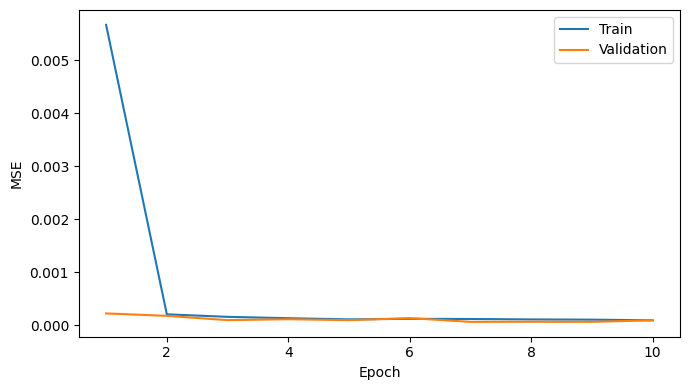

In [77]:
history = []
for epoch in range(1, cfg.epochs + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f}")

history_df = pd.DataFrame(history)
history_df.to_csv(cfg.output_dir / "autoencoder_history.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
torch.save(model.state_dict(), cfg.output_dir / "conv_autoencoder.pt")

## 5. Rekonstruktionsfehler und Latentraum-Distanz berechnen

In [79]:
@torch.no_grad()
def compute_scores(loader: DataLoader):
    model.eval()
    all_indices = []
    all_recon_errors = []
    all_latents = []
    all_recons = []

    for x, idx in loader:
        x = x.to(DEVICE)
        x_hat, z = model(x)
        mse_per_patch = F.mse_loss(x_hat, x, reduction="none").mean(dim=(1, 2, 3))

        all_indices.extend(idx.cpu().numpy().tolist())
        all_recon_errors.extend(mse_per_patch.cpu().numpy().tolist())
        all_latents.append(z.cpu().numpy())
        all_recons.append(x_hat.cpu().numpy())

    return (
        np.array(all_indices),
        np.array(all_recon_errors, dtype=np.float32),
        np.concatenate(all_latents, axis=0),
        np.concatenate(all_recons, axis=0),
    )

In [80]:
indices, recon_error, latents, reconstructions = compute_scores(full_loader)

### Zur Sicherheit in ursprüngliche Reihenfolge bringen

In [81]:
order = np.argsort(indices)
recon_error = recon_error[order]
latents = latents[order]
reconstructions = reconstructions[order]

latent_center = latents.mean(axis=0, keepdims=True)
latent_distance = np.linalg.norm(latents - latent_center, axis=1)

scaler = MinMaxScaler()
score_components = scaler.fit_transform(np.column_stack([recon_error, latent_distance]))
recon_norm = score_components[:, 0]
latent_norm = score_components[:, 1]
anomaly_score = cfg.alpha * recon_norm + (1.0 - cfg.alpha) * latent_norm

otsu_threshold = threshold_otsu(anomaly_score)
pseudo_label = (anomaly_score >= otsu_threshold).astype(int)

results = metadata.copy()
results["recon_error"] = recon_error
results["latent_distance"] = latent_distance
results["recon_norm"] = recon_norm
results["latent_norm"] = latent_norm
results["anomaly_score"] = anomaly_score
results["pseudo_label"] = pseudo_label

results.to_csv(cfg.output_dir / "pseudo_labels.csv", index=False)
print("Otsu-Schwelle:", otsu_threshold)
print(results["pseudo_label"].value_counts().rename(index={0: "regulär", 1: "anomal"}))
display(results.sort_values("anomaly_score", ascending=False).head(20))

Otsu-Schwelle: 0.086027026
pseudo_label
regulär    6694
anomal     3035
Name: count, dtype: int64


,image_path,layer,position,center_y,center_x,crop_side,recon_error,latent_distance,recon_norm,latent_norm,anomaly_score,pseudo_label
16,recoating/2021-02-18_08-38-49_layer_00003.jpg,2021,7,1091,1229,38,0.007314,114.562019,1.000000,0.458231,0.837469,1
6678,recoating/2021-02-18_12-41-07_layer_00744.jpg,2021,0,520,1034,38,0.006786,63.440697,0.927463,0.248266,0.723704,1
32,recoating/2021-02-18_08-39-26_layer_00005.jpg,2021,5,640,1426,38,0.005125,77.913460,0.699141,0.307709,0.581711,1
17,recoating/2021-02-18_08-38-49_layer_00003.jpg,2021,8,1091,1426,38,0.004629,39.005596,0.630974,0.147907,0.486054,1
35,recoating/2021-02-18_08-39-26_layer_00005.jpg,2021,8,1091,1426,38,0.004682,22.592117,0.638239,0.080493,0.470915,1
50,recoating/2021-02-18_08-40-01_layer_00007.jpg,2021,5,640,1426,38,0.003945,75.923607,0.536971,0.299536,0.465741,1
34,recoating/2021-02-18_08-39-26_layer_00005.jpg,2021,7,1091,1229,38,0.002938,100.117508,0.398464,0.398905,0.398596,1
14,recoating/2021-02-18_08-38-49_layer_00003.jpg,2021,5,640,1426,38,0.003179,75.486061,0.431711,0.297739,0.391520,1
9720,recoating/2021-02-18_14-44-42_layer_01082.jpg,2021,0,520,1034,38,0.000417,246.469330,0.052026,1.000000,0.336418,1
9693,recoating/2021-02-18_14-43-47_layer_01079.jpg,2021,0,520,1034,38,0.000702,212.932739,0.091178,0.862259,0.322502,1


## 6. Diagnoseplots und visuelle Kontrolle

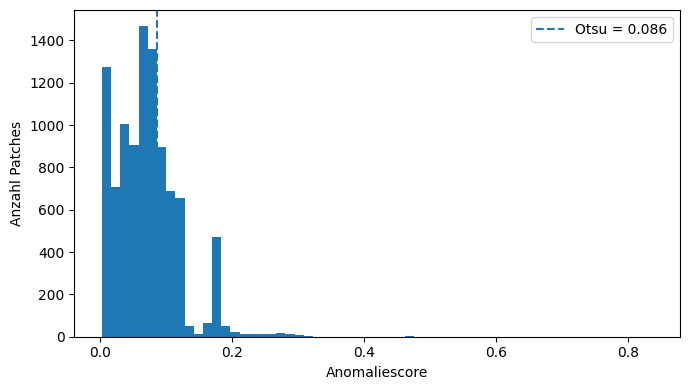

In [82]:
plt.figure(figsize=(7, 4))
plt.hist(anomaly_score, bins=60)
plt.axvline(otsu_threshold, linestyle="--", label=f"Otsu = {otsu_threshold:.3f}")
plt.xlabel("Anomaliescore")
plt.ylabel("Anzahl Patches")
plt.legend()
plt.tight_layout()
plt.show()

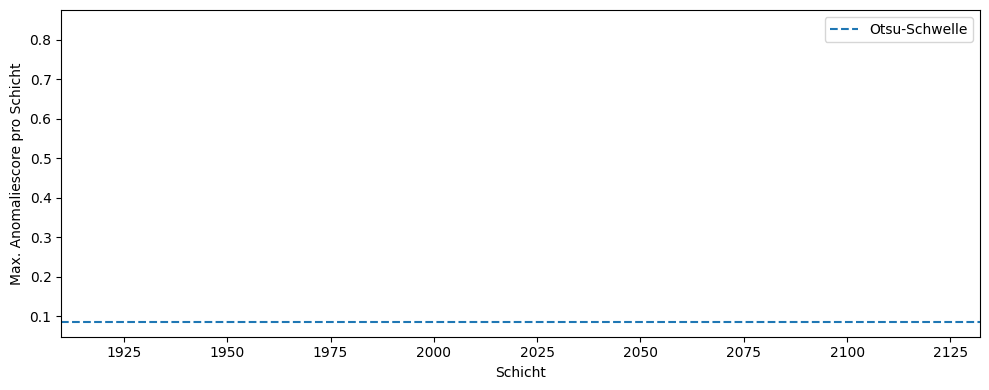

In [83]:
layer_scores = results.groupby("layer", as_index=False)["anomaly_score"].max()
plt.figure(figsize=(10, 4))
plt.plot(layer_scores["layer"], layer_scores["anomaly_score"])
plt.axhline(otsu_threshold, linestyle="--", label="Otsu-Schwelle")
plt.xlabel("Schicht")
plt.ylabel("Max. Anomaliescore pro Schicht")
plt.legend()
plt.tight_layout()
plt.show()

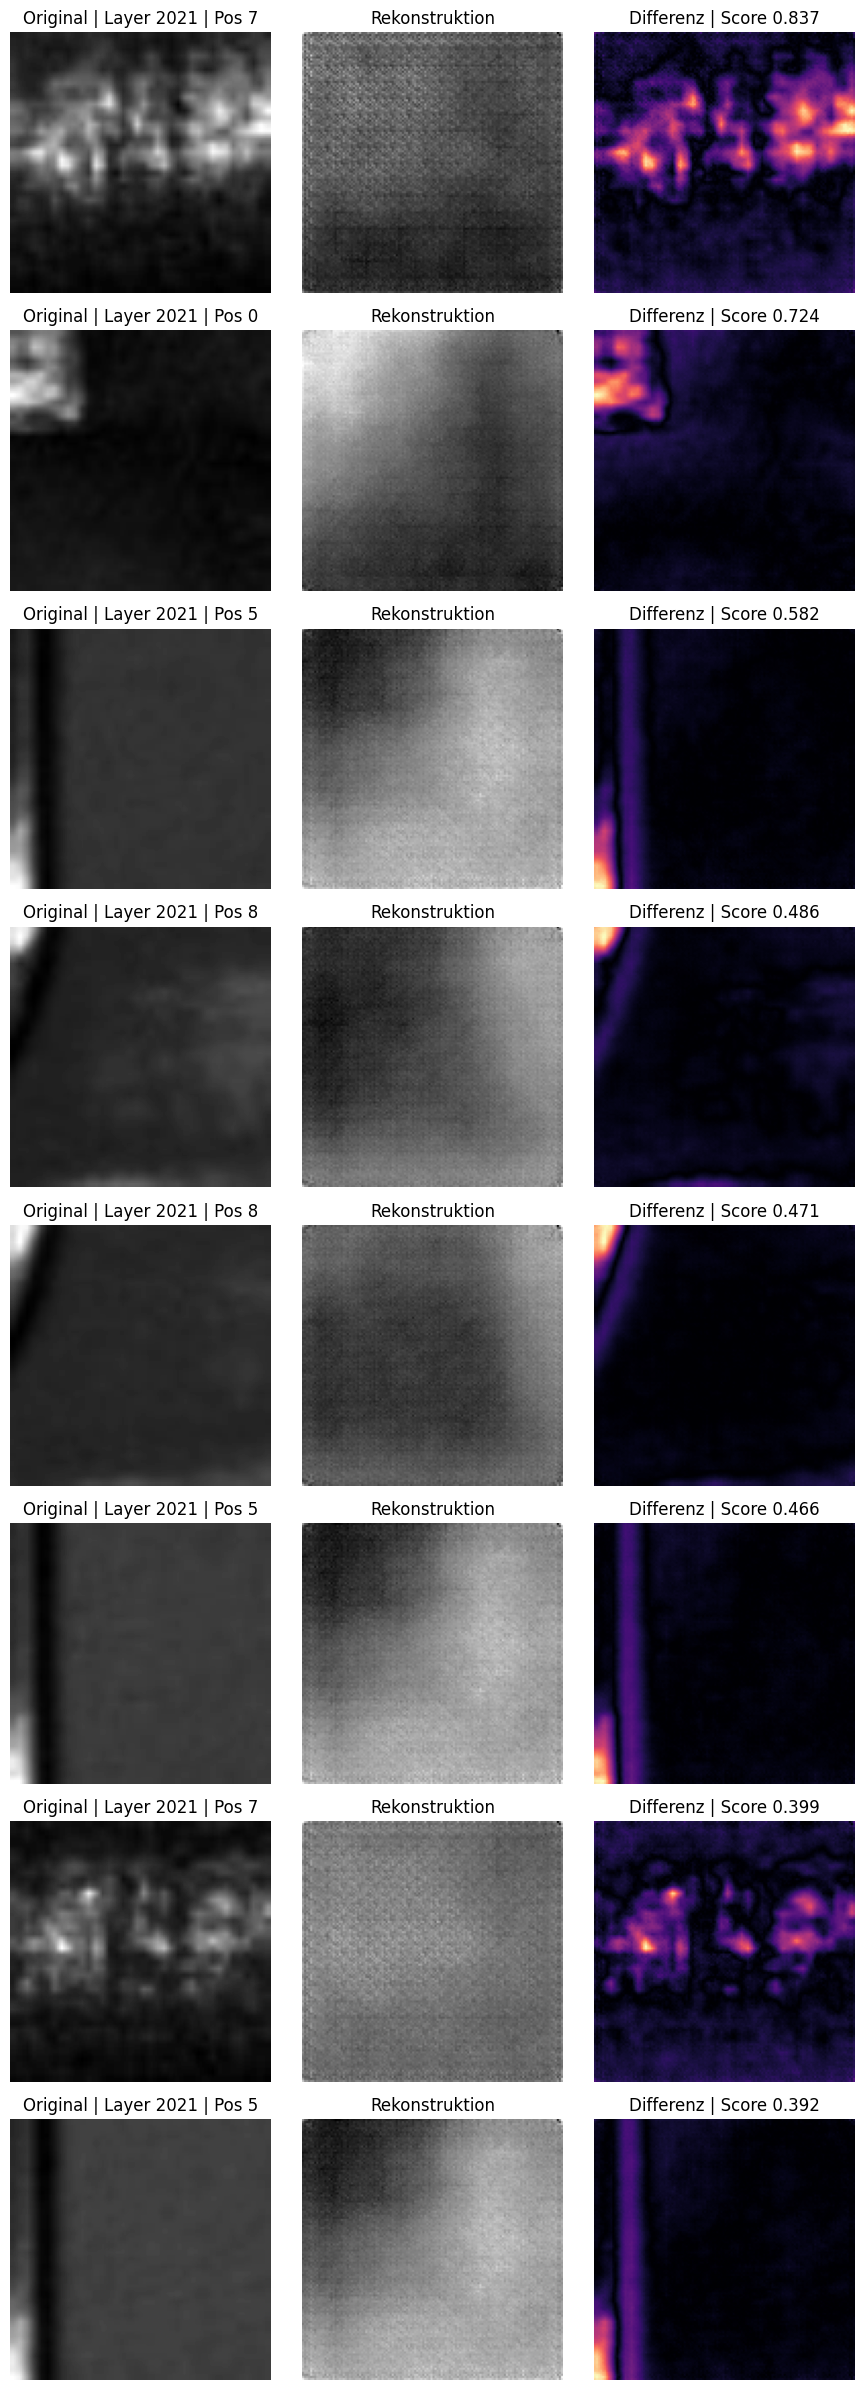

In [84]:
def show_reconstruction_examples(results_df: pd.DataFrame, n: int = 8):
    top = results_df.sort_values("anomaly_score", ascending=False).head(n)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (idx, row) in enumerate(top.iterrows()):
        original = patches[idx]
        recon = reconstructions[idx, 0]
        diff = np.abs(original - recon)

        axes[row_idx, 0].imshow(original, cmap="gray")
        axes[row_idx, 0].set_title(f"Original | Layer {row['layer']} | Pos {row['position']}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(recon, cmap="gray")
        axes[row_idx, 1].set_title("Rekonstruktion")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(diff, cmap="magma")
        axes[row_idx, 2].set_title(f"Differenz | Score {row['anomaly_score']:.3f}")
        axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()


show_reconstruction_examples(results, n=8)

## Ergebnis dieses Schritts
#
# Die Datei `outputs/pseudo_labels.csv` enthält nun pro Patch:
# - Bildpfad
# - Schichtnummer
# - Bauteilposition 0 bis 8
# - Rekonstruktionsfehler
# - Latentraum-Distanz
# - kombinierten Anomaliescore
# - Pseudo-Label `0 = regulär`, `1 = anomal`
#
# Diese CSV ist die Eingabe für den nächsten Schritt: Training einer ResNet-18-Klassifikation auf den Pseudo-Labels.
